In [3]:
import pandas as pd
df = pd.read_csv('claims_main.csv')

In [4]:
df.head()

,claim_id,claim_submission_date,claim_year,claim_quarter,payer_type,provider_specialty,place_of_service_code,place_of_service_desc,cpt_code,modifier,...,prior_auth_obtained,prior_auth_number,documentation_completeness,claim_amount_usd,outcome,denial_reason_code,denial_category,dataset_version,synthetic_flag,generation_date
0,e46071e9-0fe0-42d8-ab46-dbb0c48341c4,2022-04-22,2022,Q2,Commercial_PPO,Emergency_Medicine,23,Emergency_Room,99283,NaN,...,NaN,NaN,0.40,656.22,denied,CO-4,coding_error,2.0,True,2026-04-28
1,a641a4ce-38d4-4467-a9d3-d4970735ecc0,2022-07-24,2022,Q3,Medicare_FFS,Internal_Medicine,11,Office,99215,25,...,NaN,NaN,0.37,332.89,denied,CO-97,duplicate,2.0,True,2026-04-28
2,2bd53273-5f36-46ad-b777-0035afd1e2e7,2022-08-24,2022,Q3,Commercial_EPO,Cardiology,2,Telehealth,93000,NaN,...,NaN,NaN,0.65,185.97,denied,CO-4,bundling,2.0,True,2026-04-28
3,72df5380-e03a-4ae9-a1e0-3d3aadf13daf,2021-07-26,2021,Q3,Commercial_PPO,Physical_Therapy,11,Office,97530,59,...,NaN,NaN,0.85,157.25,paid,NaN,NaN,2.0,True,2026-04-28
4,9eb5d58c-3f62-40a9-971f-37855af76d48,2021-12-01,2021,Q4,Medicaid_Managed,Obstetrics_Gynecology,23,Emergency_Room,59400,NaN,...,False,NaN,0.38,8991.46,denied,CO-16,auth_missing,2.0,True,2026-04-28


In [5]:
print(df.shape)

(120000, 25)


In [6]:
print(df.columns)

Index(['claim_id', 'claim_submission_date', 'claim_year', 'claim_quarter',
       'payer_type', 'provider_specialty', 'place_of_service_code',
       'place_of_service_desc', 'cpt_code', 'modifier', 'primary_icd10_dx',
       'primary_icd10_desc', 'secondary_icd10_dx', 'secondary_dx_count',
       'prior_auth_required', 'prior_auth_obtained', 'prior_auth_number',
       'documentation_completeness', 'claim_amount_usd', 'outcome',
       'denial_reason_code', 'denial_category', 'dataset_version',
       'synthetic_flag', 'generation_date'],
      dtype='object')


In [7]:
print(df.columns.tolist())

['claim_id', 'claim_submission_date', 'claim_year', 'claim_quarter', 'payer_type', 'provider_specialty', 'place_of_service_code', 'place_of_service_desc', 'cpt_code', 'modifier', 'primary_icd10_dx', 'primary_icd10_desc', 'secondary_icd10_dx', 'secondary_dx_count', 'prior_auth_required', 'prior_auth_obtained', 'prior_auth_number', 'documentation_completeness', 'claim_amount_usd', 'outcome', 'denial_reason_code', 'denial_category', 'dataset_version', 'synthetic_flag', 'generation_date']


In [8]:
df['outcome'].value_counts()

outcome
paid           62379
denied         33664
partial_pay    15469
pending         8488
Name: count, dtype: int64

### Finding: Outcome Breakdown
- 52% of claims are fully paid
- 28% are outright denied  
- 13% partially paid,
- 7% still pending

**Key Finding:** Including denials, partial payments, and pending claims, **48%** of 
all claims don't result in full expected payment, a bigger revenue risk than 
denial rate alone shows.

In [9]:
df.isnull().sum()

claim_id                          0
claim_submission_date             0
claim_year                        0
claim_quarter                     0
payer_type                        0
provider_specialty                0
place_of_service_code             0
place_of_service_desc             0
cpt_code                          0
modifier                      54247
primary_icd10_dx                  0
primary_icd10_desc                0
secondary_icd10_dx            35928
secondary_dx_count                0
prior_auth_required               0
prior_auth_obtained           62488
prior_auth_number             73320
documentation_completeness        0
claim_amount_usd                  0
outcome                           0
denial_reason_code            86336
denial_category               86336
dataset_version                   0
synthetic_flag                    0
generation_date                   0
dtype: int64

In [10]:
(df.groupby('payer_type')['outcome'].value_counts(normalize=True) * 100).round(1)

payer_type          outcome    
Commercial_EPO      paid           52.0
                    denied         27.7
                    partial_pay    13.2
                    pending         7.1
Commercial_HMO      paid           51.9
                    denied         28.0
                    partial_pay    13.0
                    pending         7.0
Commercial_PPO      paid           52.1
                    denied         27.8
                    partial_pay    12.9
                    pending         7.2
Medicaid_Managed    paid           51.7
                    denied         28.5
                    partial_pay    12.6
                    pending         7.3
Medicare_Advantage  paid           52.1
                    denied         28.3
                    partial_pay    12.5
                    pending         7.1
Medicare_FFS        paid           51.9
                    denied         28.1
                    partial_pay    13.2
                    pending         6.8
Name: pr

### Finding: Denial Rate by Payer Type
- All payers show a nearly identical denial rate, ranging only 27.7% – 28.5%
  
**Key Finding:** Denial rate does not meaningfully vary by payer type, suggesting the

real driver of denials is something claim-specific (e.g. prior authorisation, 
documentation completeness) rather than the insurance company itself

In [11]:
df['prior_auth_required']

0         False
1         False
2         False
3         False
4          True
          ...  
119995     True
119996     True
119997     True
119998     True
119999     True
Name: prior_auth_required, Length: 120000, dtype: bool

In [12]:
(df.groupby('prior_auth_required')['outcome'].value_counts(normalize = True) * 100).round(1)

prior_auth_required  outcome    
False                paid           52.0
                     denied         28.1
                     partial_pay    12.9
                     pending         7.0
True                 paid           52.0
                     denied         28.0
                     partial_pay    12.9
                     pending         7.1
Name: proportion, dtype: float64

### Finding: Denial Rate by Prior Auth Required (Yes/No)
- Claims requiring prior auth: 28.0% denied
- Claims not requiring prior auth: 28.1% denied
  
- **Key Finding:** Simply requiring prior authorization doesn't affect denial rate on 
its own, nearly identical to claims that never needed it at all.
This suggests the real driver isn't the *requirement*, but whether the required authorization 
was actually *obtained* or not — testing that next.

In [13]:
(df[df['prior_auth_required'] == True].groupby('prior_auth_obtained')['outcome'].value_counts(normalize = True) * 100).round(1)

prior_auth_obtained  outcome    
False                denied         70.9
                     partial_pay    18.4
                     pending        10.8
True                 paid           60.3
                     denied         21.2
                     partial_pay    12.0
                     pending         6.5
Name: proportion, dtype: float64

### Finding: Denial Rate by Prior Authorization Obtained (among claims that required it)
- Prior auth obtained: 60.3% paid, 21.2% denied
- Prior auth NOT obtained: 0% paid, 70.9% denied
  
- **Key Finding:** Among claims requiring prior authorization, actually obtaining it makes 
a huge difference, claims with authorization have a 60% chance of full payment, while 
claims without it are almost never fully paid and get denied **71%** of the time.

Unlike payer type (which the hospital can't control), obtaining prior authorization is 
something the hospital's own staff can directly fix, making this a strong, 
actionable finding for reducing revenue leakage.

In [14]:
df[(df['prior_auth_required'] == True) & (df['prior_auth_obtained'] == False)]['claim_amount_usd'].sum()

np.float64(27849070.43)

### Finding: Dollar Impact of Missing Prior Authorization
- Total claim amount for claims that required prior authorization but did NOT obtain it: **$27,849,070.43**
  
- **Key Finding:** This is the estimated revenue tied up in a single, preventable, internally 
controllable process gap. If the hospital ensured prior authorization was always obtained 
when required, a large portion of this **~$27.8M** could likely be recovered or avoided —
making this the single most actionable, high-impact finding in the analysis so far.

In [15]:
df['documentation_completeness'].unique()

array([0.4 , 0.37, 0.65, 0.85, 0.38, 0.39, 0.97, 0.68, 0.81, 0.42, 0.86,
       0.82, 0.87, 0.92, 0.79, 0.75, 0.41, 0.89, 0.8 , 0.83, 1.  , 0.77,
       0.78, 0.95, 0.29, 0.49, 0.43, 0.88, 0.98, 0.7 , 0.58, 0.56, 0.99,
       0.25, 0.59, 0.55, 0.53, 0.94, 0.51, 0.24, 0.76, 0.57, 0.6 , 0.54,
       0.34, 0.64, 0.96, 0.67, 0.69, 0.9 , 0.84, 0.91, 0.52, 0.32, 0.93,
       0.71, 0.28, 0.46, 0.3 , 0.61, 0.5 , 0.26, 0.35, 0.21, 0.22, 0.72,
       0.63, 0.66, 0.48, 0.31, 0.73, 0.45, 0.33, 0.27, 0.62, 0.36, 0.44,
       0.47, 0.74, 0.23, 0.2 ])

In [16]:
df['documentation_completeness'].describe()

count    120000.000000
mean          0.724929
std           0.200389
min           0.200000
25%           0.580000
50%           0.780000
75%           0.880000
max           1.000000
Name: documentation_completeness, dtype: float64

In [17]:
df['completeness_bucket'] = pd.cut(df['documentation_completeness'], 
                                     bins=[0, 0.58, 0.78, 0.88, 1.0], 
                                     labels=['Low', 'Medium', 'High', 'Very High'])

In [18]:
df['completeness_bucket'].value_counts()

completeness_bucket
High         30456
Low          30455
Medium       30108
Very High    28981
Name: count, dtype: int64

In [19]:
(df.groupby('completeness_bucket')['outcome'].value_counts(normalize=True) * 100).round(1)

/var/folders/tm/gjtfn2014rl93dq2b634tl700000gn/T/ipykernel_69854/2147780981.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby('completeness_bucket')['outcome'].value_counts(normalize=True) * 100).round(1)


completeness_bucket  outcome    
Low                  denied         87.9
                     partial_pay     6.3
                     pending         5.8
                     paid            0.0
Medium               partial_pay    33.9
                     paid           29.0
                     denied         22.9
                     pending        14.2
High                 paid           82.0
                     partial_pay    11.0
                     pending         7.0
                     denied          0.0
Very High            paid           98.9
                     pending         1.1
                     denied          0.0
                     partial_pay     0.0
Name: proportion, dtype: float64

### Finding: Denial Rate by Documentation Completeness
- Low completeness (bottom 25%): 87.9% denied, 0% paid
- Medium completeness: 22.9% denied, 29.0% paid
- High completeness: 0% denied, 82.0% paid
  
- Very High completeness (top 25%): 0% denied, 98.9% paid
- **Key Finding:** Documentation completeness shows the strongest relationship with claim 
outcome found in this analysis, claims with poor documentation are almost never paid, 
while claims with excellent documentation are almost always paid in full. This is a 
near step-function pattern: as documentation quality improves, denial risk drops 
sharply

Like prior authorization, this is an internally controllable factor, making 
it a top priority recommendation — improving documentation quality before submission 
could dramatically reduce denials and recover significant revenue.

In [20]:
df['claim_amount_usd'].describe()

count    120000.000000
mean       2223.581352
std        4089.863423
min          52.240000
25%         242.730000
50%         433.270000
75%        2556.855000
max       37918.580000
Name: claim_amount_usd, dtype: float64

In [21]:
df['amount_bucket'] = pd.cut(df['claim_amount_usd'], 
                               bins=[0, 242.73, 433.27, 2556.86, 37918.58], 
                               labels=['Low', 'Medium', 'High', 'Very High'])

In [22]:
df['amount_bucket'].value_counts()

amount_bucket
Medium       30002
Low          30001
Very High    30000
High         29997
Name: count, dtype: int64

In [23]:
(df.groupby('amount_bucket')['outcome'].value_counts(normalize=True) * 100).round(1)

/var/folders/tm/gjtfn2014rl93dq2b634tl700000gn/T/ipykernel_69854/1302818820.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby('amount_bucket')['outcome'].value_counts(normalize=True) * 100).round(1)


amount_bucket  outcome    
Low            paid           52.0
               denied         28.1
               partial_pay    12.8
               pending         7.1
Medium         paid           52.0
               denied         28.1
               partial_pay    12.9
               pending         7.0
High           paid           52.0
               denied         27.8
               partial_pay    12.9
               pending         7.2
Very High      paid           51.9
               denied         28.1
               partial_pay    13.0
               pending         7.0
Name: proportion, dtype: float64

### Finding: Denial Rate by Claim Amount
- Denial rate is nearly identical across all claim amount buckets (~28%), whether 
the claim is under USD 243 or over USD 2,557

- **Key Finding:** Claim size does not drive denial risk, ruling out "insurers deny 
expensive claims more" as a hypothesis. This reinforces that the real drivers of 
denial are process-related factors (documentation completeness, prior authorization), 
not the dollar value of the claim itself.

In [24]:
import matplotlib.pyplot as plt

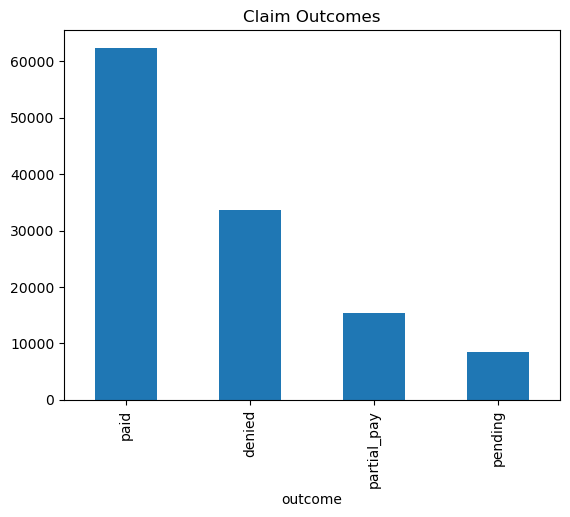

In [25]:
# Overall Claim Outcome Breakdown
# Visualizes the split of all 120,000 claims across paid, denied, partial pay, and pending

df['outcome'].value_counts().plot(kind='bar')
plt.title('Claim Outcomes')
plt.show()

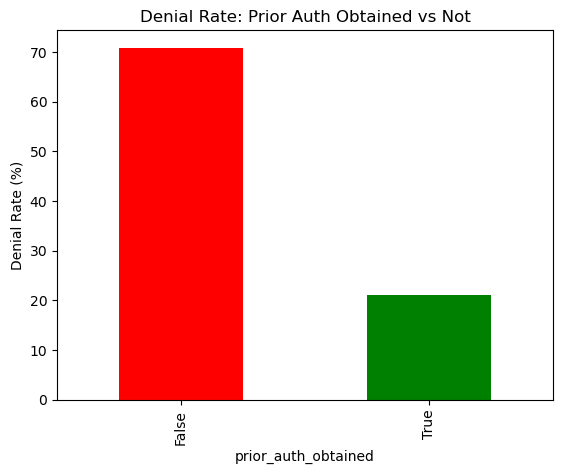

In [26]:
# Denial Rate: Prior Authorization Obtained vs Not
# Visualizes the sharp difference in denial rate depending on whether required prior authorization was actually obtained - 71% denied when missing, vs 21% when obtained

denial_by_auth = df[df['prior_auth_required'] == True].groupby('prior_auth_obtained')['outcome'].apply(lambda x: (x == 'denied').mean() * 100)
denial_by_auth.plot(kind='bar', color=['red', 'green'])
plt.title('Denial Rate: Prior Auth Obtained vs Not')
plt.ylabel('Denial Rate (%)')
plt.show()

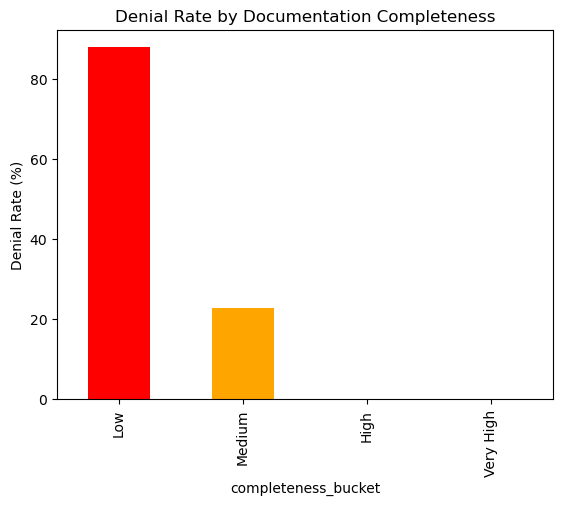

In [27]:
# Denial Rate by Documentation Completeness
# Claims with poor documentation are denied ~88% of the time, while claims with excellent documentation are almost never denied, the strongest single driver found in this analysis

completeness_denial = df.groupby('completeness_bucket', observed=True)['outcome'].apply(lambda x: (x == 'denied').mean() * 100)
completeness_denial = completeness_denial.reindex(['Low', 'Medium', 'High', 'Very High'])
completeness_denial.plot(kind='bar', color=['red', 'orange', 'yellowgreen', 'green'])
plt.title('Denial Rate by Documentation Completeness')
plt.ylabel('Denial Rate (%)')
plt.show()

In [28]:
df.columns.tolist()

['claim_id',
 'claim_submission_date',
 'claim_year',
 'claim_quarter',
 'payer_type',
 'provider_specialty',
 'place_of_service_code',
 'place_of_service_desc',
 'cpt_code',
 'modifier',
 'primary_icd10_dx',
 'primary_icd10_desc',
 'secondary_icd10_dx',
 'secondary_dx_count',
 'prior_auth_required',
 'prior_auth_obtained',
 'prior_auth_number',
 'documentation_completeness',
 'claim_amount_usd',
 'outcome',
 'denial_reason_code',
 'denial_category',
 'dataset_version',
 'synthetic_flag',
 'generation_date',
 'completeness_bucket',
 'amount_bucket']

In [29]:
df.to_csv('claims_for_powerbi.csv', index=False)

In [30]:
summary_by_completeness = df.groupby('completeness_bucket', observed=True)['outcome'].value_counts(normalize=True).unstack() * 100
summary_by_completeness.to_csv('summary_completeness.csv')
summary_by_completeness

outcome,denied,paid,partial_pay,pending
completeness_bucket,,,,
Low,87.946150,NaN,6.274832,5.779018
Medium,22.851069,28.998937,33.931181,14.218812
High,NaN,82.046231,10.973207,6.980562
Very High,NaN,98.892378,NaN,1.107622


In [31]:
summary_by_auth = df[df['prior_auth_required'] == True].groupby('prior_auth_obtained')['outcome'].value_counts(normalize=True).unstack() * 100
summary_by_auth.to_csv('summary_prior_auth.csv')
summary_by_auth

outcome,denied,paid,partial_pay,pending
prior_auth_obtained,,,,
False,70.875601,NaN,18.366257,10.758142
True,21.165381,60.344901,11.973008,6.516710
